<a href="https://colab.research.google.com/github/Gunjan3472/ML-Week-2/blob/main/Assignment_1_Week_3_01901022025.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

# Suppress warnings for cleaner output
import warnings
warnings.filterwarnings('ignore')

url = 'https://raw.githubusercontent.com/Gunjan3472/ML-Week-2/refs/heads/main/Ml_Week3/agriculture_yield_dataset.csv'
df = pd.read_csv(url)

In [2]:
print("--- Q1: Dataset Overview ---")
print(f"Rows: {df.shape[0]}, Columns: {df.shape[1]}")
print("\nColumn Names:")
print(df.columns.tolist())
print("\nFirst 10 records:")
display(df.head(10)) # 'display' looks cleaner in Colab than 'print'

--- Q1: Dataset Overview ---
Rows: 1500, Columns: 8

Column Names:
['rainfall_mm', 'temperature_c', 'fertilizer_kg', 'irrigation_hours', 'soil_ph', 'crop_type', 'soil_type', 'yield_ton_per_hectare']

First 10 records:


,rainfall_mm,temperature_c,fertilizer_kg,irrigation_hours,soil_ph,crop_type,soil_type,yield_ton_per_hectare
0,588.6,18.6,242.4,6.5,6.5,Maize,Loamy,5.92
1,772.8,34.6,247.2,10.0,6.5,Maize,Sandy,6.24
2,970.9,36.3,168.4,7.3,6.4,Wheat,Sandy,4.77
3,611.7,19.0,121.7,3.7,6.0,Maize,Loamy,4.04
4,696.1,29.6,184.6,5.1,6.1,Cotton,Clay,5.17
5,831.9,28.0,190.3,2.1,6.1,Soybean,Loamy,5.50
6,1023.8,32.0,108.5,6.9,6.2,Cotton,Loamy,5.44
7,1142.4,18.4,241.9,4.1,7.3,Soybean,Sandy,5.88
8,810.4,36.4,164.8,9.9,6.5,Wheat,Loamy,6.35
9,1085.5,29.4,89.3,8.3,5.8,Cotton,Loamy,6.30


In [3]:
print("--- Q2: Data Types and Missing Values ---")
print("Data Types:")
print(df.dtypes)

print("\nMissing Values:")
missing_values = df.isnull().sum()
print(missing_values)

if missing_values.sum() > 0:
    print("\nColumns affected by missing values:")
    print(missing_values[missing_values > 0].index.tolist())
else:
    print("\nNo missing values present.")

--- Q2: Data Types and Missing Values ---
Data Types:
rainfall_mm              float64
temperature_c            float64
fertilizer_kg            float64
irrigation_hours         float64
soil_ph                  float64
crop_type                 object
soil_type                 object
yield_ton_per_hectare    float64
dtype: object

Missing Values:
rainfall_mm              0
temperature_c            0
fertilizer_kg            0
irrigation_hours         0
soil_ph                  0
crop_type                0
soil_type                0
yield_ton_per_hectare    0
dtype: int64

No missing values present.


In [4]:
print("--- Q3: Descriptive Statistics ---")
summary_stats = df.describe()
display(summary_stats)

# Programmatically finding the highest mean and std
means = df.mean(numeric_only=True)
stds = df.std(numeric_only=True)

print(f"\nFeature with highest mean: {means.idxmax()} ({means.max():.2f})")
print(f"Feature with highest standard deviation: {stds.idxmax()} ({stds.max():.2f})")

--- Q3: Descriptive Statistics ---


,rainfall_mm,temperature_c,fertilizer_kg,irrigation_hours,soil_ph,yield_ton_per_hectare
count,1500.000000,1500.000000,1500.000000,1500.000000,1500.000000,1500.000000
mean,754.054667,27.749467,148.744067,5.403267,6.759133,5.028793
std,255.097216,5.758101,56.990279,2.584329,0.719742,0.968282
min,300.200000,18.000000,50.300000,1.000000,5.500000,2.090000
25%,536.175000,22.600000,98.600000,3.200000,6.100000,4.337500
50%,761.200000,27.700000,146.850000,5.400000,6.800000,5.010000
75%,964.375000,32.600000,196.575000,7.600000,7.400000,5.740000
max,1200.000000,38.000000,249.900000,10.000000,8.000000,7.860000



Feature with highest mean: rainfall_mm (754.05)
Feature with highest standard deviation: rainfall_mm (255.10)


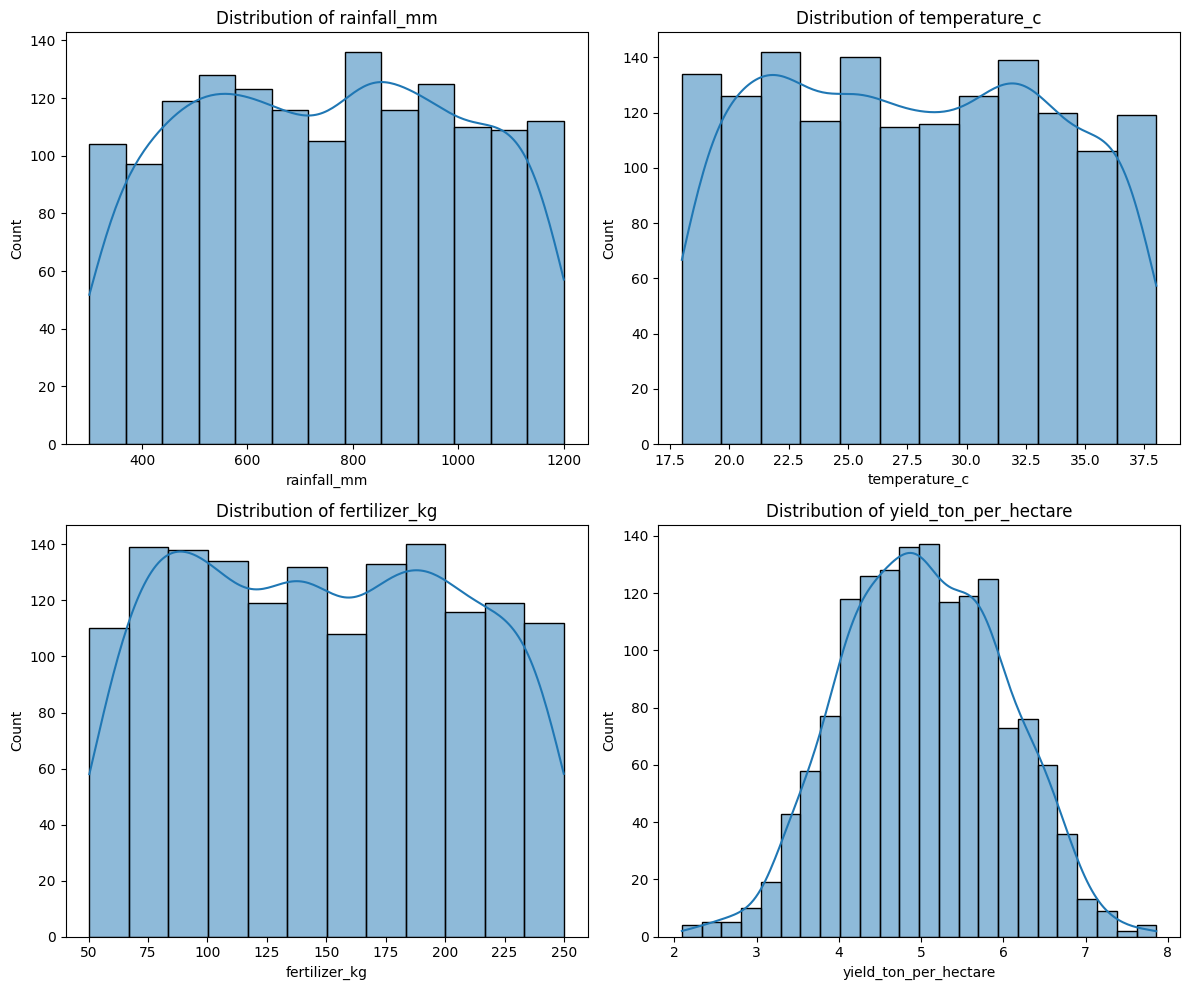


--- Q4 Observations (Write these in a text cell in Colab) ---
* Look at the plots above.
* Note if they look symmetrical (bell-curve) or skewed (leaning to one side).
* Note if there are any obvious gaps or isolated peaks.



In [5]:
# Create histograms
features_to_plot = ['rainfall_mm', 'temperature_c', 'fertilizer_kg', 'yield_ton_per_hectare']

fig, axes = plt.subplots(2, 2, figsize=(12, 10))
for i, feature in enumerate(features_to_plot):
    row, col = i // 2, i % 2
    sns.histplot(df[feature], kde=True, ax=axes[row, col])
    axes[row, col].set_title(f'Distribution of {feature}')

plt.tight_layout()
plt.show()

print("""
--- Q4 Observations
* Look at the plots above.
* Note if they look symmetrical (bell-curve) or skewed (leaning to one side).
* Note if there are any obvious gaps or isolated peaks.
""")

--- Q5: Crop Type Analysis ---
crop_type
Cotton     311
Soybean    306
Wheat      303
Rice       293
Maize      287
Name: count, dtype: int64

Most frequent crop: Cotton


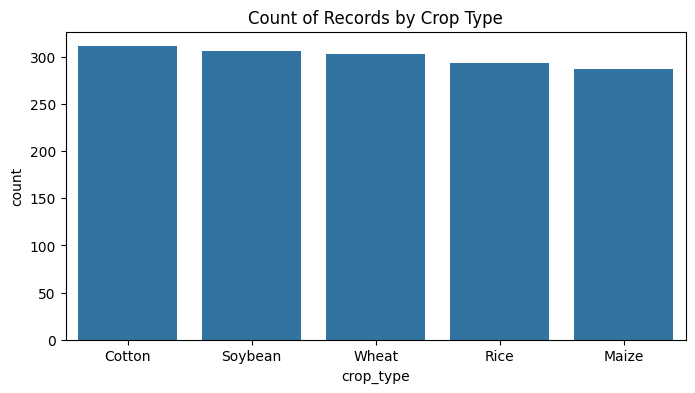


--- Q6: Soil Type Analysis ---
soil_type
Clay     534
Sandy    492
Loamy    474
Name: count, dtype: int64

Most common soil type: Clay


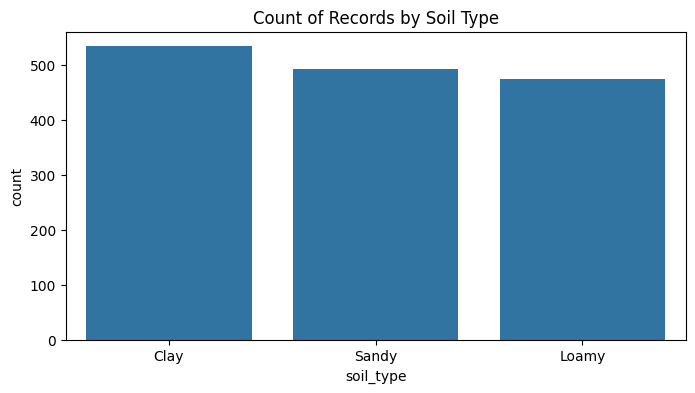

In [7]:
print("--- Q5: Crop Type Analysis ---")
crop_counts = df['crop_type'].value_counts()
print(crop_counts)
print(f"\nMost frequent crop: {crop_counts.idxmax()}")

plt.figure(figsize=(8, 4))
sns.countplot(data=df, x='crop_type', order=crop_counts.index)
plt.title('Count of Records by Crop Type')
plt.show()

print("\n--- Q6: Soil Type Analysis ---")
soil_counts = df['soil_type'].value_counts()
print(soil_counts)
print(f"\nMost common soil type: {soil_counts.idxmax()}")

plt.figure(figsize=(8, 4))
sns.countplot(data=df, x='soil_type', order=soil_counts.index)
plt.title('Count of Records by Soil Type')
plt.show()

--- Q7: Yield Distribution ---


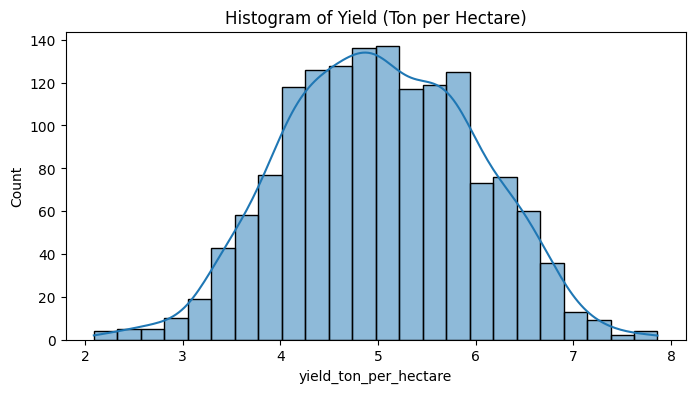

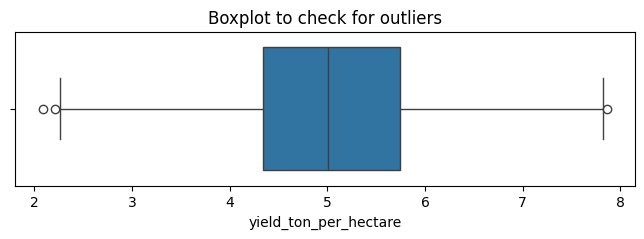


--- Q7 Answer (Write in text cell) ---
* Check the histogram: Does it look like a normal distribution (bell shape)?
* Check the boxplot: Dots outside the "whiskers" indicate noticeable outliers.



In [8]:
print("--- Q7: Yield Distribution ---")
plt.figure(figsize=(8, 4))
sns.histplot(df['yield_ton_per_hectare'], kde=True)
plt.title('Histogram of Yield (Ton per Hectare)')
plt.show()

plt.figure(figsize=(8, 2))
sns.boxplot(x=df['yield_ton_per_hectare'])
plt.title('Boxplot to check for outliers')
plt.show()

print("""
--- Q7 Answer
* Check the histogram: Does it look like a normal distribution (bell shape)?
* Check the boxplot: Dots outside the "whiskers" indicate noticeable outliers.
""")

--- Q8: Scatter Plot Analysis ---


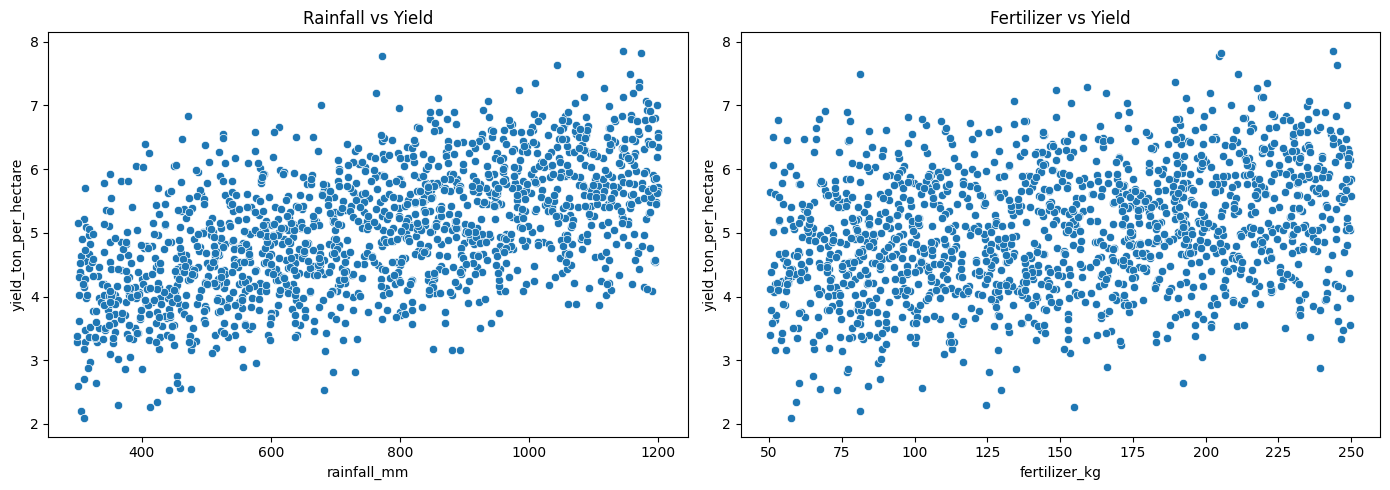


--- Q8 Answer
* Look at the plots: Which dots form a tighter, clearer pattern or line going upwards? That feature has the stronger relationship.



In [9]:
print("--- Q8: Scatter Plot Analysis ---")
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.scatterplot(data=df, x='rainfall_mm', y='yield_ton_per_hectare', ax=axes[0])
axes[0].set_title('Rainfall vs Yield')

sns.scatterplot(data=df, x='fertilizer_kg', y='yield_ton_per_hectare', ax=axes[1])
axes[1].set_title('Fertilizer vs Yield')

plt.tight_layout()
plt.show()

print("""
--- Q8 Answer
* Look at the plots: Which dots form a tighter, clearer pattern or line going upwards? That feature has the stronger relationship.
""")

--- Q9: Correlation Analysis ---


,rainfall_mm,temperature_c,fertilizer_kg,irrigation_hours,soil_ph,yield_ton_per_hectare
rainfall_mm,1.000000,0.026721,0.002558,0.010877,0.006916,0.553704
temperature_c,0.026721,1.000000,0.037468,0.007114,0.001513,-0.022559
fertilizer_kg,0.002558,0.037468,1.000000,-0.010497,0.010001,0.278043
irrigation_hours,0.010877,0.007114,-0.010497,1.000000,0.009307,0.542664
soil_ph,0.006916,0.001513,0.010001,0.009307,1.000000,0.024412
yield_ton_per_hectare,0.553704,-0.022559,0.278043,0.542664,0.024412,1.000000


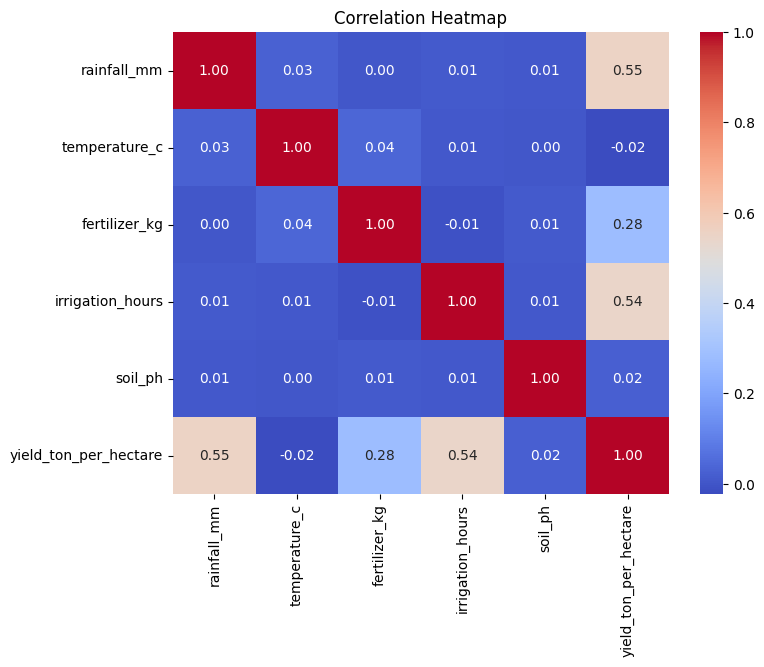


Top three features most correlated with crop yield:
rainfall_mm         0.553704
irrigation_hours    0.542664
fertilizer_kg       0.278043
Name: yield_ton_per_hectare, dtype: float64


In [10]:
print("--- Q9: Correlation Analysis ---")
# Only calculate correlation for numeric columns
corr_matrix = df.corr(numeric_only=True)
display(corr_matrix)

plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Heatmap')
plt.show()

# Find top 3 features correlated with yield
yield_corr = corr_matrix['yield_ton_per_hectare'].drop('yield_ton_per_hectare') # drop itself
top_3_features = yield_corr.abs().sort_values(ascending=False).head(3)
print(f"\nTop three features most correlated with crop yield:\n{top_3_features}")

In [11]:
print("--- Q10: Group-Based Analysis ---")
avg_yield_crop = df.groupby('crop_type')['yield_ton_per_hectare'].mean().sort_values(ascending=False)
print("Average yield for each crop type:")
print(avg_yield_crop)

avg_yield_soil = df.groupby('soil_type')['yield_ton_per_hectare'].mean().sort_values(ascending=False)
print("\nAverage yield for each soil type:")
print(avg_yield_soil)

print(f"\nCrop with highest average yield: {avg_yield_crop.idxmax()}")
print(f"Soil type with highest average yield: {avg_yield_soil.idxmax()}")

--- Q10: Group-Based Analysis ---
Average yield for each crop type:
crop_type
Rice       5.494744
Soybean    5.173431
Wheat      4.989472
Maize      4.897143
Cotton     4.607299
Name: yield_ton_per_hectare, dtype: float64

Average yield for each soil type:
soil_type
Loamy    5.366519
Clay     5.134326
Sandy    4.588882
Name: yield_ton_per_hectare, dtype: float64

Crop with highest average yield: Rice
Soil type with highest average yield: Loamy


In [12]:
print("--- Q11: Feature Encoding ---")
# Identify categorical columns (object dtype)
categorical_cols = df.select_dtypes(include=['object']).columns.tolist()
print(f"Categorical columns identified: {categorical_cols}")

# Apply One-Hot Encoding (drop_first=True prevents multicollinearity)
df_encoded = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

print("\nFirst five rows of the transformed dataset:")
display(df_encoded.head())

--- Q11: Feature Encoding ---
Categorical columns identified: ['crop_type', 'soil_type']

First five rows of the transformed dataset:


,rainfall_mm,temperature_c,fertilizer_kg,irrigation_hours,soil_ph,yield_ton_per_hectare,crop_type_Maize,crop_type_Rice,crop_type_Soybean,crop_type_Wheat,soil_type_Loamy,soil_type_Sandy
0,588.6,18.6,242.4,6.5,6.5,5.92,True,False,False,False,True,False
1,772.8,34.6,247.2,10.0,6.5,6.24,True,False,False,False,False,True
2,970.9,36.3,168.4,7.3,6.4,4.77,False,False,False,True,False,True
3,611.7,19.0,121.7,3.7,6.0,4.04,True,False,False,False,True,False
4,696.1,29.6,184.6,5.1,6.1,5.17,False,False,False,False,False,False


In [13]:
print("--- Q12: Feature Selection ---")
# Target variable is yield_ton_per_hectare
target = 'yield_ton_per_hectare'

X = df_encoded.drop(columns=[target])
y = df_encoded[target]

print(f"Target variable (y): {target}")
print(f"Input features (X) columns: {X.columns.tolist()}")

--- Q12: Feature Selection ---
Target variable (y): yield_ton_per_hectare
Input features (X) columns: ['rainfall_mm', 'temperature_c', 'fertilizer_kg', 'irrigation_hours', 'soil_ph', 'crop_type_Maize', 'crop_type_Rice', 'crop_type_Soybean', 'crop_type_Wheat', 'soil_type_Loamy', 'soil_type_Sandy']


In [14]:
print("--- Q13: Train-Test Split ---")
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)

print("Shapes of the splits:")
print(f"X_train: {X_train.shape}")
print(f"X_test: {X_test.shape}")
print(f"y_train: {y_train.shape}")
print(f"y_test: {y_test.shape}")

--- Q13: Train-Test Split ---
Shapes of the splits:
X_train: (1200, 11)
X_test: (300, 11)
y_train: (1200,)
y_test: (300,)


In [16]:
print("--- Q14: Linear Regression Model ---")
# Initialize and Train
model = LinearRegression()
model.fit(X_train, y_train)

# Coefficients and Intercept
print(f"Model Intercept: {model.intercept_:.4f}\n")

coefficients = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': model.coef_
})
print("Model Coefficients:")
display(coefficients)

# Find highest positive coefficient
highest_coef = coefficients.loc[coefficients['Coefficient'].idxmax()]
print(f"\nFeature with the highest positive coefficient is '{highest_coef['Feature']}' with a value of {highest_coef['Coefficient']:.4f}")

--- Q14: Linear Regression Model ---
Model Intercept: 1.5871

Model Coefficients:


,Feature,Coefficient
0,rainfall_mm,0.002035
1,temperature_c,-0.009175
2,fertilizer_kg,0.004978
3,irrigation_hours,0.198327
4,soil_ph,0.004901
5,crop_type_Maize,0.238931
6,crop_type_Rice,0.863993
7,crop_type_Soybean,0.481719
8,crop_type_Wheat,0.348474
9,soil_type_Loamy,0.302974



Feature with the highest positive coefficient is 'crop_type_Rice' with a value of 0.8640
